In [1]:
!pip install pennylane pennylane-lightning -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 45.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 61.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 101.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 13.6 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import pennylane as qml
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

n_qubits = 8
dev = qml.device("lightning.qubit", wires=n_qubits)

N_EPOCHS      = 8
BATCH_SIZE    = 32
LEARNING_RATE = 0.001
TRAIN_SUBSET  = 1500
TEST_SUBSET   = 500

NOISE_LEVELS = [0.0, 0.05, 0.10]

BRAIN_TRAIN_DIR = ("/kaggle/input/datasets/masoudnickparvar/"
                   "brain-tumor-mri-dataset/Training")
BRAIN_TEST_DIR  = ("/kaggle/input/datasets/masoudnickparvar/"
                   "brain-tumor-mri-dataset/Testing")

Using device: cuda


In [4]:
@qml.qnode(dev, interface="torch", diff_method="adjoint")
def quantum_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
    num_layers = weights.shape[0]
    for layer in range(num_layers):
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])
        for i in range(n_qubits):
            qml.RZ(weights[layer, i], wires=i)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

weight_shapes = {"weights": (8, n_qubits)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

In [5]:
class QuantumAlexNet(nn.Module):
    def __init__(self, q_layer, n_qubits, n_classes=4):
        super(QuantumAlexNet, self).__init__()

        alexnet = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
        self.features = alexnet.features

        for param in self.features.parameters():
            param.requires_grad = False

        self.avgpool = alexnet.avgpool
        self.flatten = nn.Flatten()

        self.dense1 = nn.Linear(9216, 512)
        self.bn1    = nn.BatchNorm1d(512)
        self.act1   = nn.LeakyReLU(0.1)

        self.dense2 = nn.Linear(512, 128)
        self.bn2    = nn.BatchNorm1d(128)
        self.act2   = nn.LeakyReLU(0.1)

        self.linear_reduction = nn.Linear(128, n_qubits)
        self.quantum_layer    = q_layer
        self.classifier       = nn.Linear(n_qubits, n_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.flatten(x)

        x = self.act1(self.bn1(self.dense1(x)))
        x = self.act2(self.bn2(self.dense2(x)))

        x = self.linear_reduction(x)
        x = torch.sin(x) * (np.pi / 2)

        quantum_outputs = [self.quantum_layer(item) for item in x]
        x = torch.stack(quantum_outputs)
        x = self.classifier(x)
        return x

In [6]:
class AddGaussianNoise:
    def __init__(self, std=0.0):
        self.std = std

    def __call__(self, tensor):
        if self.std == 0.0:
            return tensor
        return torch.clamp(tensor + torch.randn_like(tensor) * self.std, 0.0, 1.0)


In [7]:
def build_loaders_brain(noise_std=0.0):
    noise_step = [AddGaussianNoise(std=noise_std)] if noise_std > 0.0 else []

    tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ] + noise_step)

    train_full = datasets.ImageFolder(root=BRAIN_TRAIN_DIR, transform=tf)
    test_full  = datasets.ImageFolder(root=BRAIN_TEST_DIR,  transform=tf)

    train_loader = DataLoader(
        Subset(train_full, list(range(min(TRAIN_SUBSET, len(train_full))))),
        batch_size=BATCH_SIZE, shuffle=True,
    )
    test_loader = DataLoader(
        Subset(test_full, list(range(min(TEST_SUBSET, len(test_full))))),
        batch_size=BATCH_SIZE, shuffle=False,
    )

    print(f"Brain MRI | noise={noise_std} | train={min(TRAIN_SUBSET, len(train_full))} | test={min(TEST_SUBSET, len(test_full))} | classes=4")
    return train_loader, test_loader

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(dim=1) == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total


In [9]:
def run_experiment_brain(noise_std):
    print(f"\nBrain MRI | noise={int(noise_std * 100)}%")
    print("-" * 40)

    train_loader, test_loader = build_loaders_brain(noise_std=noise_std)
    model     = QuantumAlexNet(quantum_layer, n_qubits, n_classes=4).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        te_loss, te_acc = evaluate(model, test_loader, criterion, DEVICE)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)

        print(f"Epoch [{epoch}/{N_EPOCHS}] "
              f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc*100:.2f}% | "
              f"Test Loss: {te_loss:.4f} | Test Acc: {te_acc*100:.2f}%")

    return history

In [10]:
results = {}
for noise in NOISE_LEVELS:
    results[noise] = run_experiment_brain(noise)
print("\nAll experiments complete.")


Brain MRI | noise=0%
----------------------------------------
Brain MRI | noise=0.0 | train=1500 | test=500 | classes=4
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 178MB/s]  


Epoch [1/8] Train Loss: 0.7292 | Train Acc: 92.80% | Test Loss: 0.7057 | Test Acc: 80.00%
Epoch [2/8] Train Loss: 0.4566 | Train Acc: 93.33% | Test Loss: 0.5566 | Test Acc: 80.00%
Epoch [3/8] Train Loss: 0.3087 | Train Acc: 93.33% | Test Loss: 0.4820 | Test Acc: 80.00%
Epoch [4/8] Train Loss: 0.2264 | Train Acc: 93.33% | Test Loss: 0.4828 | Test Acc: 80.00%
Epoch [5/8] Train Loss: 0.1827 | Train Acc: 93.33% | Test Loss: 0.4470 | Test Acc: 80.00%
Epoch [6/8] Train Loss: 0.1567 | Train Acc: 93.33% | Test Loss: 0.4200 | Test Acc: 80.00%
Epoch [7/8] Train Loss: 0.1367 | Train Acc: 93.33% | Test Loss: 0.4299 | Test Acc: 80.00%
Epoch [8/8] Train Loss: 0.1266 | Train Acc: 93.33% | Test Loss: 0.4201 | Test Acc: 80.00%

Brain MRI | noise=5%
----------------------------------------
Brain MRI | noise=0.05 | train=1500 | test=500 | classes=4
Epoch [1/8] Train Loss: 0.8699 | Train Acc: 76.20% | Test Loss: 0.9143 | Test Acc: 77.80%
Epoch [2/8] Train Loss: 0.5757 | Train Acc: 93.53% | Test Loss: 0.75

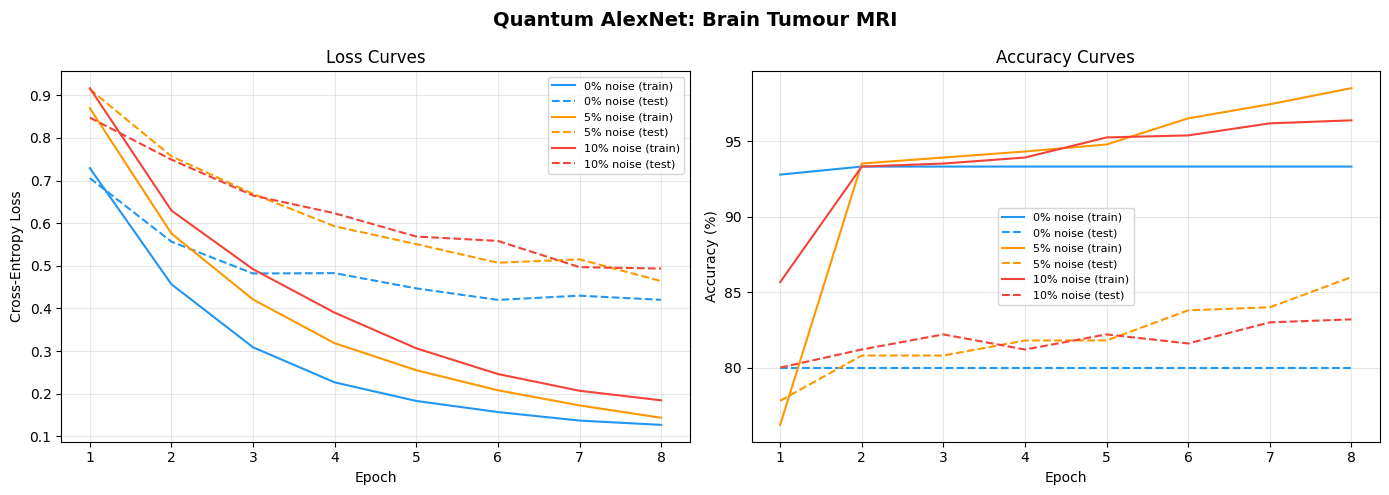

In [11]:
def plot_metrics(results):
    epochs       = list(range(1, N_EPOCHS + 1))
    noise_labels = {0.0: "0% noise", 0.05: "5% noise", 0.10: "10% noise"}
    colors       = {0.0: "#2196F3",  0.05: "#FF9800",  0.10: "#F44336"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Quantum AlexNet: Brain Tumour MRI", fontsize=14, fontweight="bold")
    ax_loss, ax_acc = axes

    for noise, history in results.items():
        c = colors[noise]; l = noise_labels[noise]
        ax_loss.plot(epochs, history["train_loss"], color=c, ls="-",  label=f"{l} (train)")
        ax_loss.plot(epochs, history["test_loss"],  color=c, ls="--", label=f"{l} (test)")
        ax_acc.plot(epochs,  [a*100 for a in history["train_acc"]], color=c, ls="-",  label=f"{l} (train)")
        ax_acc.plot(epochs,  [a*100 for a in history["test_acc"]],  color=c, ls="--", label=f"{l} (test)")

    for ax, ylabel, title in zip(
        [ax_loss, ax_acc],
        ["Cross-Entropy Loss", "Accuracy (%)"],
        ["Loss Curves", "Accuracy Curves"]
    ):
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("quantum_alexnet_brain.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_metrics(results)

In [12]:
def print_summary(results):
    header = f"{'Noise':>8} {'Final Test Acc':>16} {'Final Test Loss':>16}"
    print("\nBrain Tumour MRI - Final Epoch Results")
    print(header)
    for noise, history in results.items():
        print(f"{int(noise*100):>7}%  {history['test_acc'][-1]*100:>15.2f}%  {history['test_loss'][-1]:>16.4f}")
print_summary(results)


Brain Tumour MRI - Final Epoch Results
   Noise   Final Test Acc  Final Test Loss
      0%            80.00%            0.4201
      5%            86.00%            0.4641
     10%            83.20%            0.4935
